# Lifetime PD — the evidence

Every statistic below is a tested function in `creditsurv`. This notebook calls them
and shows what came back; it contains no statistics of its own. Read
[`docs/variable_selection.md`](../docs/variable_selection.md) for the procedure and
the thresholds, and [`docs/data_dictionary.md`](../docs/data_dictionary.md) for what
the fields mean.

The **fit itself is not here**. On the whole population it is tens of minutes, so it
is a CLI step — `creditsurv fit` and `creditsurv report` — and this notebook reads
what they leave behind. That is the same division as
[`01_portfolio.ipynb`](01_portfolio.ipynb): the package computes, the commands
persist, the notebook shows.

In [1]:
import warnings
from pathlib import Path

import pandas as pd
from IPython.display import Image

from creditsurv.config import reports_dir
from creditsurv.data.fred import load_macro_panel
from creditsurv.data.panel import WEIGHT, cells_to_episodes
from creditsurv.data.store import load_cells
from creditsurv.explore import curves_cross, default_rate_by_band, survival_by_stratum
from creditsurv.features import BIN_EDGES, bin_covariates
from creditsurv.models.selection import inflation_from_covariance
from creditsurv.reporting.selection import TABLE_FILES

warnings.simplefilter("ignore", FutureWarning)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

# The cells, not the expanded panel. Every table below reads a loan-month count, an age, an
# event flag and a covariate the cell key already holds; expanding all 63.6 million cells
# with every macro candidate would peak near 13 GB to answer none of them.
cells = load_cells()
print(f"{len(cells):,} cells")
print(f"{int(cells[WEIGHT].sum()):,} loan-months")
print(f"{int(cells.loc[cells['event'], WEIGHT].sum()):,} defaults")
print(f"ages {cells['age'].min()} to {cells['age'].max()} months")

63,639,116 cells
2,535,194,125 loan-months
1,536,686 defaults
ages 0 to 326 months


## 1. Can one survival function serve?

The project's commitment is to **a single survival function**, with heterogeneity
carried by covariates rather than by segmenting the book. That is an assumption, and
this is the check that can refuse it before any model is fitted.

Curves that separate and stay separated are exactly what a model with covariates is
for: the covariate shifts the scale and one functional form serves. Curves that
**cross** cannot be reconciled by scaling one into the other, and no coefficient will
fix it.

Kaplan-Meier over individual loans is not available on an aggregated panel. The curve
below is the same construction — an empirical hazard per age, chained — computed on
exposure, which is what the estimator reduces to on weighted cells.

In [2]:
from creditsurv.explore import MIN_EXPOSURE_FOR_CROSSING

for stratum in ("purpose", "occupancy", "term_years"):
    curves = survival_by_stratum(cells, stratum)
    # The same floor the crossing test applies: a thirty-year book has ages nobody
    # reached, and a survival estimate on a handful of loan-months is noise.
    thick = curves[curves["exposure"] >= MIN_EXPOSURE_FOR_CROSSING]
    final = thick.sort_values("age").groupby("stratum", observed=True).last()

    print(f"{stratum}: curves cross = {curves_cross(curves)}")
    print(final[["age", "survival", "exposure"]].round(4).to_string())
    print()

purpose: curves cross = False
                     age  survival  exposure
stratum                                     
purchase             280    0.8163   10198.0
refinance_cashout    275    0.7973   10508.0
refinance_rate_term  278    0.8599   10182.0



occupancy: curves cross = False
                age  survival  exposure
stratum                                
investor        238    0.8670   10287.0
owner_occupied  291    0.8156   10948.0
second_home     221    0.8952   10158.0



term_years: curves cross = False
         age  survival  exposure
stratum                         
15       180    0.9406   73549.0
30       292    0.7954   10793.0



## 2. Does each covariate order the risk?

The rate is **events over exposure** — a monthly hazard — not defaults over loans.
Two bands can hold the same number of defaults and differ entirely in risk if one was
watched ten times as long, and across twenty-seven vintages that is the rule rather
than the exception.

What to look for is monotonicity. A covariate whose default rate rises and falls
across its own bands is either mis-binned or proxying something else — which is how
the untreated `999` sentinel in estimated LTV was found.

In [3]:
# The origination covariates are carried at their band's midpoint in the cell key. The
# macro-derived ones are rebuilt continuous -- only the three shown -- and banded from the
# same BIN_EDGES the model's binned formula would use.
macro_banded = ["cltv_drift", "rate_gap", "hpi_growth"]
episodes = cells_to_episodes(cells, load_macro_panel(), covariates=macro_banded)
banded = bin_covariates(
    episodes.loc[:, [*macro_banded, WEIGHT, "event"]],
    edges={name: BIN_EDGES[name] for name in macro_banded},
)
del episodes

for name, frame in (
    ("fico_s", cells),
    ("orig_ltv", cells),
    ("dti", cells),
    ("term_years", cells),
    ("cltv_drift_binned", banded),
    ("rate_gap_binned", banded),
    ("hpi_growth_binned", banded),
):
    table = default_rate_by_band(frame, name)
    rate = table["default_rate"]
    monotone = rate.is_monotonic_increasing or rate.is_monotonic_decreasing
    print(f"{name}  (monotone: {monotone})")
    print(table.round(6).to_string(index=False))
    print()

fico_s  (monotone: True)
 level     exposure   events  default_rate    share
  -1.6  178854658.0 455691.0      0.002548 0.070549
  -0.4  330697233.0 411807.0      0.001245 0.130443
   0.4  525497785.0 340915.0      0.000649 0.207281
   1.0  344836528.0 129218.0      0.000375 0.136020
   1.8 1155307921.0 199055.0      0.000172 0.455708



orig_ltv  (monotone: True)
 level     exposure   events  default_rate    share
  50.0 1106476605.0 415115.0      0.000375 0.436447
  75.0  973760707.0 660810.0      0.000679 0.384097
  85.0  220526292.0 218412.0      0.000990 0.086986
  95.0  234430521.0 242349.0      0.001034 0.092470



dti  (monotone: True)
 level    exposure   events  default_rate    share
  19.0 905029809.0 298969.0      0.000330 0.356986
  32.0 615288596.0 341784.0      0.000555 0.242699
  39.5 540736505.0 398873.0      0.000738 0.213292
  49.0 474139215.0 497060.0      0.001048 0.187023



term_years  (monotone: True)
 level     exposure    events  default_rate    share
    15  670117307.0  164674.0      0.000246 0.264326
    30 1865076818.0 1372012.0      0.000736 0.735674



cltv_drift_binned  (monotone: False)
 level    exposure   events  default_rate    share
 -40.0 404119210.0 194134.0      0.000480 0.159404
 -15.0 714462016.0 296633.0      0.000415 0.281817
  -7.5 493477511.0 216277.0      0.000438 0.194651
  -2.5 570270949.0 184121.0      0.000323 0.224942
   2.5 183414123.0 112496.0      0.000613 0.072347
   7.5  70294490.0 134380.0      0.001912 0.027727
  15.0  78628903.0 296892.0      0.003776 0.031015
  50.0  20526923.0 101753.0      0.004957 0.008097



rate_gap_binned  (monotone: False)
 level    exposure   events  default_rate    share
 -4.00 426281042.0 126900.0      0.000298 0.168145
 -1.50 123535428.0  42671.0      0.000345 0.048728
 -0.75 234185537.0  80894.0      0.000345 0.092374
 -0.25 459889514.0 147432.0      0.000321 0.181402
  0.25 475453800.0 181220.0      0.000381 0.187541
  0.75 325596551.0 247851.0      0.000761 0.128431
  1.50 349219203.0 490096.0      0.001403 0.137749
  4.00 141033050.0 219622.0      0.001557 0.055630



hpi_growth_binned  (monotone: False)
 level    exposure   events  default_rate    share
-0.300  80048403.0 155146.0      0.001938 0.031575
-0.075 131171620.0 198476.0      0.001513 0.051740
-0.025 323822327.0 382551.0      0.001181 0.127731
 0.025 751870447.0 302262.0      0.000402 0.296573
 0.075 753175046.0 314205.0      0.000417 0.297088
 0.125 318841500.0 133072.0      0.000417 0.125766
 0.325 176264782.0  50974.0      0.000289 0.069527



## 3. Collinearity

Seventeen candidates, of which thirteen come from fourteen macroeconomic series. Five
of those series are interest rates, and as *time series* they move as one thing over
1999–2026, so this is where the specification was expected to fail.

It does not, and the reason is the panel structure rather than luck: the design matrix
is indexed by vintage and age rather than calendar time, and the gap-since-origination
covariates project onto that second dimension. `docs/variable_selection.md` sets out
the argument and the corollary — replace the gaps with levels and the collinearity
returns at full strength.

In [4]:
# Steps 5 and 6 as `creditsurv select` computed them, on the training half of the whole
# population: the numbers the specification was chosen on, not a second set.
tables = Path(reports_dir())
correlation_file = tables / TABLE_FILES["correlation"]

if correlation_file.exists():
    correlation = pd.read_csv(correlation_file, index_col=0)
    collinear = pd.read_csv(tables / TABLE_FILES["collinear"])
    print(f"pairs above |rho| = 0.8: {len(collinear)}")

    pairs = (
        correlation.stack()
        .rename("correlation")
        .reset_index()
        .rename(columns={"level_0": "first", "level_1": "second"})
    )
    pairs = pairs[pairs["first"] < pairs["second"]]
    pairs = pairs.reindex(pairs["correlation"].abs().sort_values(ascending=False).index)
    print()
    print("strongest pairs:")
    print(pairs.head(8).round(3).to_string(index=False))
else:
    print(f"No selection tables in {tables}. Run: uv run creditsurv select")

pairs above |rho| = 0.8: 1



strongest pairs:
          first        second  correlation
policy_rate_gap      rate_gap       -0.800
      inflation inflation_gap        0.762
    nfci_lagged           vix        0.732
  credit_spread   nfci_lagged        0.728
policy_rate_gap   term_spread       -0.727
  credit_spread           vix        0.723
            vix       vix_gap        0.648
       rate_gap   term_spread        0.633


In [5]:
if correlation_file.exists():
    vif = inflation_from_covariance(correlation)
    removed = pd.read_csv(tables / TABLE_FILES["inflation"])
    print(f"above VIF = 10: {(vif['vif'] > 10).sum()}; removed stepwise: {len(removed)}")
    display(vif.round(2))
else:
    print(f"No selection tables in {tables}. Run: uv run creditsurv select")

above VIF = 10: 1; removed stepwise: 1


,covariate,vif,tolerance
0,credit_spread,11.90,0.08
1,nfci_lagged,7.51,0.13
2,inflation,6.10,0.16
3,policy_rate_gap,5.95,0.17
4,vix,4.19,0.24
5,rate_gap,4.10,0.24
6,term_spread,3.49,0.29
7,hpi_growth,3.33,0.30
8,inflation_gap,3.12,0.32
9,starts_growth,2.61,0.38


## 4. The fitted model

From `creditsurv fit`, which persists its coefficient table because a fit on this
table is tens of minutes and nothing downstream should pay for one twice.

This is an **accelerated failure time** model, so a coefficient acts on the logarithm
of survival *time*: positive lengthens expected survival and therefore **lowers**
risk. `exp(coef)` is a **time ratio, not a hazard ratio** — reading it as one inverts
the sign of every conclusion.

In [6]:
coefficients = Path(reports_dir()) / "coefficients.csv"

if coefficients.exists():
    table = pd.read_csv(coefficients, index_col=[0, 1])
    display(table.round(4))
else:
    print(f"No coefficients at {coefficients}. Run: uv run creditsurv fit")

coef  se(coef)  time_ratio  coef lower 95%  coef upper 95%      p
param   covariate                                                                                                              
lambda_ Intercept                                           8.3070    0.0079   4052.0510          8.2914          8.3225  0.000
        fico_s                                              0.4144    0.0006      1.5135          0.4132          0.4156  0.000
        orig_ltv                                           -0.0129    0.0001      0.9872         -0.0130         -0.0128  0.000
        dti                                                -0.0156    0.0001      0.9845         -0.0157         -0.0155  0.000
        cltv_drift                                         -0.0167    0.0001      0.9834         -0.0169         -0.0166  0.000
        unemp_gap                                          -0.0353    0.0004      0.9653         -0.0360         -0.0346  0.000
        nfci_lagged                                        -0.0065    0.0012      0.9935         -0.0089         -0.0042  0.000
        policy_rate_gap                                     0.0538    0.0004      1.0553          0.0531          0.0546  0.000
        sentiment                                           0.0068    0.0001      1.0068          0.0066          0.0069  0.000
        starts_growth                                       0.3920    0.0039      1.4799          0.3844          0.3996  0.000
        inflation_gap                                       2.4701    0.0346     11.8242          2.4023          2.5380  0.000
        term_years                                         -0.0361    0.0001      0.9646         -0.0363         -0.0358  0.000
        C(purpose, Treatment('purchase'))[T.refinance_c... -0.2968    0.0017      0.7432         -0.3001         -0.2934  0.000
        C(purpose, Treatment('purchase'))[T.refinance_r... -0.0875    0.0017      0.9162         -0.0909         -0.0841  0.000
        C(occupancy, Treatment('owner_occupied'))[T.inv... -0.0679    0.0026      0.9343         -0.0730         -0.0629  0.000
        C(occupancy, Treatment('owner_occupied'))[T.sec...  0.0960    0.0035      1.1008          0.0892          0.1029  0.000
        C(has_mi, Treatment('N'))[T.Y]                     -0.1020    0.0019      0.9030         -0.1057         -0.0984  0.000
        C(first_time_buyer, Treatment('N'))[T.Y]           -0.0025    0.0021      0.9975         -0.0066          0.0016  0.225
rho_    Intercept                                           0.3516    0.0007      1.4214          0.3502          0.3531  0.000

## 5. Against the non-parametric estimate

The strongest evidence available, because the Kaplan-Meier curve assumes nothing
about the distribution. A fitted curve straying outside its confidence band is being
contradicted by the data rather than merely smoothing it.

The curve is chained from the model's monthly hazard along each cell's *realised*
covariate path, not predicted from origination covariates and averaged. The
difference is not cosmetic: `cltv_drift` and `unemp_gap` are zero at origination by
construction, so freezing them there assumes house prices never move and unemployment
never changes. An earlier version of this comparison did exactly that and put only
half the horizon inside the band.

From `creditsurv report`.

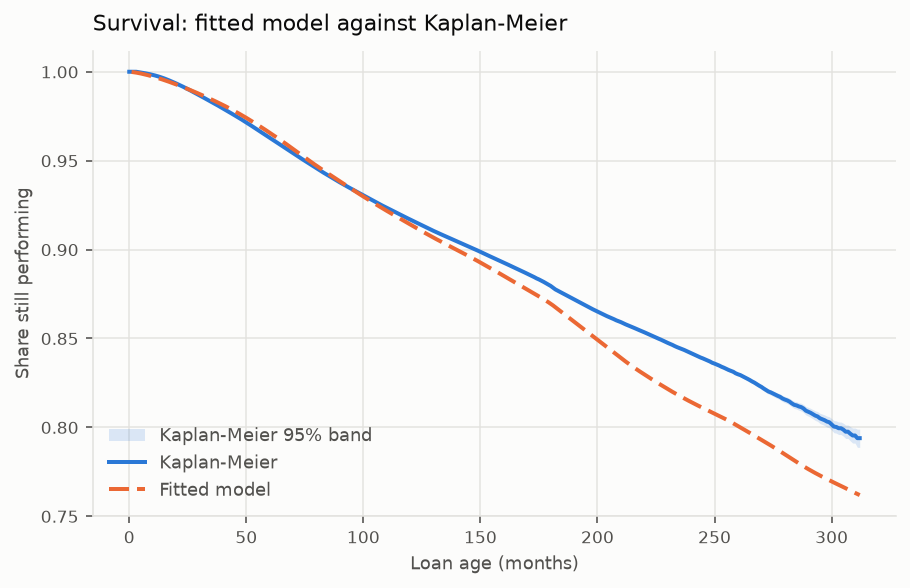

In [7]:
figure = Path(reports_dir()) / "figures" / "survival_vs_km.png"

if figure.exists():
    display(Image(str(figure)))
else:
    print(f"No figure at {figure}. Run: uv run creditsurv report")